# Importing Data

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
orders = pd.read_csv('/content/orders.csv', encoding='latin-1')
order_details = pd.read_csv('/content/order_details.csv', encoding='latin-1')
pizzas = pd.read_csv('/content/pizzas.csv', encoding='latin-1')
pizza_types = pd.read_csv('/content/pizza_types.csv', encoding='latin-1')

 # Preprocessing

## Orders Table

In [7]:
orders.sample(10)

,order_id,date,time
2165,2166,2015-02-05,20:41:36
7867,7868,2015-05-12,18:49:37
17395,17396,2015-10-23,13:03:06
4740,4741,2015-03-21,14:06:09
10445,10446,2015-06-24,21:35:35
19804,19805,2015-12-03,13:02:05
14293,14294,2015-08-27,11:58:52
1724,1725,2015-01-29,21:27:53
3568,3569,2015-03-01,19:39:29
3663,3664,2015-03-03,15:55:09


In [8]:
orders.set_index('order_id',inplace=True)

In [9]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21350 entries, 1 to 21350
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    21350 non-null  object
 1   time    21350 non-null  object
dtypes: object(2)
memory usage: 500.4+ KB


In [10]:
orders.duplicated().sum()

np.int64(0)

In [11]:
orders['date'].unique()

array(['2015-01-01', '2015-01-02', '2015-01-03', '2015-01-04',
       '2015-01-05', '2015-01-06', '2015-01-07', '2015-01-08',
       '2015-01-09', '2015-01-10', '2015-01-11', '2015-01-12',
       '2015-01-13', '2015-01-14', '2015-01-15', '2015-01-16',
       '2015-01-17', '2015-01-18', '2015-01-19', '2015-01-20',
       '2015-01-21', '2015-01-22', '2015-01-23', '2015-01-24',
       '2015-01-25', '2015-01-26', '2015-01-27', '2015-01-28',
       '2015-01-29', '2015-01-30', '2015-01-31', '2015-02-01',
       '2015-02-02', '2015-02-03', '2015-02-04', '2015-02-05',
       '2015-02-06', '2015-02-07', '2015-02-08', '2015-02-09',
       '2015-02-10', '2015-02-11', '2015-02-12', '2015-02-13',
       '2015-02-14', '2015-02-15', '2015-02-16', '2015-02-17',
       '2015-02-18', '2015-02-19', '2015-02-20', '2015-02-21',
       '2015-02-22', '2015-02-23', '2015-02-24', '2015-02-25',
       '2015-02-26', '2015-02-27', '2015-02-28', '2015-03-01',
       '2015-03-02', '2015-03-03', '2015-03-04', '2015-

In [12]:
orders['date'] = pd.to_datetime(orders['date'])

In [13]:
orders['time'] = pd.to_datetime(orders['time'])

/tmp/ipython-input-251407178.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  orders['time'] = pd.to_datetime(orders['time'])


In [14]:
orders

,date,time
order_id,,
1,2015-01-01,2025-11-27 11:38:36
2,2015-01-01,2025-11-27 11:57:40
3,2015-01-01,2025-11-27 12:12:28
4,2015-01-01,2025-11-27 12:16:31
5,2015-01-01,2025-11-27 12:21:30
...,...,...
21346,2015-12-31,2025-11-27 20:51:07
21347,2015-12-31,2025-11-27 21:14:37
21348,2015-12-31,2025-11-27 21:23:10


In [15]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21350 entries, 1 to 21350
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    21350 non-null  datetime64[ns]
 1   time    21350 non-null  datetime64[ns]
dtypes: datetime64[ns](2)
memory usage: 500.4 KB


In [16]:
orders['Hour'] = orders['time'].dt.hour

In [17]:
orders['time'] = orders['time'].dt.strftime('%H:%M:%S')

In [18]:
orders['day'] = orders['date'].dt.day

In [19]:
orders['day of the week'] = orders['date'].dt.day_name()

In [20]:
orders['month'] = orders['date'].dt.month

## Order Details Table

In [21]:
order_details

,order_details_id,order_id,pizza_id,quantity
0,1,1,hawaiian_m,1
1,2,2,classic_dlx_m,1
2,3,2,five_cheese_l,1
3,4,2,ital_supr_l,1
4,5,2,mexicana_m,1
...,...,...,...,...
48615,48616,21348,ckn_alfredo_m,1
48616,48617,21348,four_cheese_l,1
48617,48618,21348,napolitana_s,1
48618,48619,21349,mexicana_l,1


In [22]:
order_details.set_index('order_details_id',inplace=True)

In [23]:
order_details.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48620 entries, 1 to 48620
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   order_id  48620 non-null  int64 
 1   pizza_id  48620 non-null  object
 2   quantity  48620 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 1.5+ MB


In [24]:
order_details.duplicated().sum()

np.int64(0)

In [25]:
order_details.sample(10)

,order_id,pizza_id,quantity
order_details_id,,,
41595,18301,classic_dlx_m,1
46203,20292,veggie_veg_m,1
37400,16505,four_cheese_l,1
11792,5184,classic_dlx_m,1
33965,15000,prsc_argla_m,1
48112,21145,spicy_ital_m,1
43966,19324,thai_ckn_l,1
47301,20786,sicilian_l,1
27406,12058,four_cheese_l,1


## Pizzas Tables

In [26]:
pizzas.head(5)

,pizza_id,pizza_type_id,size,price
0,bbq_ckn_s,bbq_ckn,S,12.75
1,bbq_ckn_m,bbq_ckn,M,16.75
2,bbq_ckn_l,bbq_ckn,L,20.75
3,cali_ckn_s,cali_ckn,S,12.75
4,cali_ckn_m,cali_ckn,M,16.75


In [27]:
pizzas.duplicated().sum()

np.int64(0)

In [28]:
pizzas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   pizza_id       96 non-null     object 
 1   pizza_type_id  96 non-null     object 
 2   size           96 non-null     object 
 3   price          96 non-null     float64
dtypes: float64(1), object(3)
memory usage: 3.1+ KB


## Pizza types Table

In [29]:
pizza_types.sample(5)

,pizza_type_id,name,category,ingredients
5,thai_ckn,The Thai Chicken Pizza,Chicken,"Chicken, Pineapple, Tomatoes, Red Peppers, Tha..."
6,big_meat,The Big Meat Pizza,Classic,"Bacon, Pepperoni, Italian Sausage, Chorizo Sau..."
17,peppr_salami,The Pepper Salami Pizza,Supreme,"Genoa Salami, Capocollo, Pepperoni, Tomatoes, ..."
30,spinach_fet,The Spinach and Feta Pizza,Veggie,"Spinach, Mushrooms, Red Onions, Feta Cheese, G..."
1,cali_ckn,The California Chicken Pizza,Chicken,"Chicken, Artichoke, Spinach, Garlic, Jalapeno ..."


In [30]:
pizza_types.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   pizza_type_id  32 non-null     object
 1   name           32 non-null     object
 2   category       32 non-null     object
 3   ingredients    32 non-null     object
dtypes: object(4)
memory usage: 1.1+ KB


In [31]:
pizza_types.duplicated().sum()

np.int64(0)

In [32]:
orders.head(1)


,date,time,Hour,day,day of the week,month
order_id,,,,,,
1,2015-01-01,11:38:36,11,1,Thursday,1


In [33]:
order_details.head(1)


,order_id,pizza_id,quantity
order_details_id,,,
1,1,hawaiian_m,1


In [34]:
pizzas.head(1)

,pizza_id,pizza_type_id,size,price
0,bbq_ckn_s,bbq_ckn,S,12.75


In [35]:
pizza_types.head(1)

,pizza_type_id,name,category,ingredients
0,bbq_ckn,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,..."


# Merging Tables



In [36]:
New = pd.merge(order_details,orders,on='order_id',how='inner')

In [37]:
New

,order_id,pizza_id,quantity,date,time,Hour,day,day of the week,month
0,1,hawaiian_m,1,2015-01-01,11:38:36,11,1,Thursday,1
1,2,classic_dlx_m,1,2015-01-01,11:57:40,11,1,Thursday,1
2,2,five_cheese_l,1,2015-01-01,11:57:40,11,1,Thursday,1
3,2,ital_supr_l,1,2015-01-01,11:57:40,11,1,Thursday,1
4,2,mexicana_m,1,2015-01-01,11:57:40,11,1,Thursday,1
...,...,...,...,...,...,...,...,...,...
48615,21348,ckn_alfredo_m,1,2015-12-31,21:23:10,21,31,Thursday,12
48616,21348,four_cheese_l,1,2015-12-31,21:23:10,21,31,Thursday,12
48617,21348,napolitana_s,1,2015-12-31,21:23:10,21,31,Thursday,12
48618,21349,mexicana_l,1,2015-12-31,22:09:54,22,31,Thursday,12


In [38]:
New = pd.merge(New,pizzas,on='pizza_id',how='inner')

In [39]:
New.head(2)

,order_id,pizza_id,quantity,date,time,Hour,day,day of the week,month,pizza_type_id,size,price
0,1,hawaiian_m,1,2015-01-01,11:38:36,11,1,Thursday,1,hawaiian,M,13.25
1,2,classic_dlx_m,1,2015-01-01,11:57:40,11,1,Thursday,1,classic_dlx,M,16.00


In [40]:
pizza_types.head(2)

,pizza_type_id,name,category,ingredients
0,bbq_ckn,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,..."
1,cali_ckn,The California Chicken Pizza,Chicken,"Chicken, Artichoke, Spinach, Garlic, Jalapeno ..."


In [41]:
New = pd.merge(New,pizza_types,on='pizza_type_id',how='inner')

In [42]:
New.head(2)

,order_id,pizza_id,quantity,date,time,Hour,day,day of the week,month,pizza_type_id,size,price,name,category,ingredients
0,1,hawaiian_m,1,2015-01-01,11:38:36,11,1,Thursday,1,hawaiian,M,13.25,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese"
1,2,classic_dlx_m,1,2015-01-01,11:57:40,11,1,Thursday,1,classic_dlx,M,16.00,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,..."


In [43]:
New['Revenue'] = New['price'] * New['quantity']

In [44]:
New.sample(5)

,order_id,pizza_id,quantity,date,time,Hour,day,day of the week,month,pizza_type_id,size,price,name,category,ingredients,Revenue
44889,19731,prsc_argla_m,1,2015-12-01,22:24:48,22,1,Tuesday,12,prsc_argla,M,16.50,The Prosciutto and Arugula Pizza,Supreme,"Prosciutto di San Daniele, Arugula, Mozzarella...",16.50
8019,3519,four_cheese_l,1,2015-02-28,20:42:48,20,28,Saturday,2,four_cheese,L,17.95,The Four Cheese Pizza,Veggie,"Ricotta Cheese, Gorgonzola Piccante Cheese, Mo...",17.95
11173,4902,pep_msh_pep_s,1,2015-03-24,15:31:33,15,24,Tuesday,3,pep_msh_pep,S,11.00,"The Pepperoni, Mushroom, and Peppers Pizza",Classic,"Pepperoni, Mushrooms, Green Peppers",11.00
17927,7865,hawaiian_l,1,2015-05-12,18:21:44,18,12,Tuesday,5,hawaiian,L,16.50,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",16.50
42153,18542,green_garden_m,1,2015-11-12,18:40:11,18,12,Thursday,11,green_garden,M,16.00,The Green Garden Pizza,Veggie,"Spinach, Mushrooms, Tomatoes, Green Olives, Fe...",16.00


In [45]:
New.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   order_id         48620 non-null  int64         
 1   pizza_id         48620 non-null  object        
 2   quantity         48620 non-null  int64         
 3   date             48620 non-null  datetime64[ns]
 4   time             48620 non-null  object        
 5   Hour             48620 non-null  int32         
 6   day              48620 non-null  int32         
 7   day of the week  48620 non-null  object        
 8   month            48620 non-null  int32         
 9   pizza_type_id    48620 non-null  object        
 10  size             48620 non-null  object        
 11  price            48620 non-null  float64       
 12  name             48620 non-null  object        
 13  category         48620 non-null  object        
 14  ingredients      48620 non-null  objec

In [46]:
New.duplicated().sum()

np.int64(0)

In [47]:
New = New[['date','time','order_id','name','size','price','quantity','Revenue','category','Hour','day',
    'day of the week','month','ingredients','pizza_id','pizza_type_id']]

In [48]:
New.describe().round(2)

,date,order_id,price,quantity,Revenue,Hour,day,month
count,48620,48620.00,48620.00,48620.00,48620.00,48620.00,48620.00,48620.00
mean,2015-06-29 11:03:43.611682560,10701.48,16.49,1.02,16.82,15.91,15.46,6.45
min,2015-01-01 00:00:00,1.00,9.75,1.00,9.75,9.00,1.00,1.00
25%,2015-03-31 00:00:00,5337.00,12.75,1.00,12.75,13.00,8.00,3.00
50%,2015-06-28 00:00:00,10682.50,16.50,1.00,16.50,16.00,15.00,6.00
75%,2015-09-28 00:00:00,16100.00,20.25,1.00,20.50,18.00,23.00,9.00
max,2015-12-31 00:00:00,21350.00,35.95,4.00,83.00,23.00,31.00,12.00
std,NaN,6180.12,3.62,0.14,4.44,3.15,8.81,3.44


array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >], dtype=object)

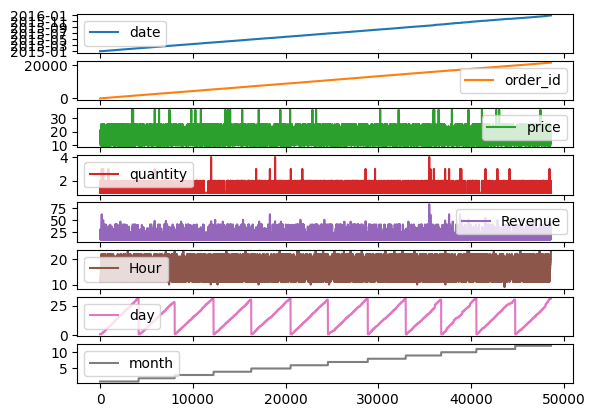

In [49]:
 New.plot(subplots = True)


<Axes: >

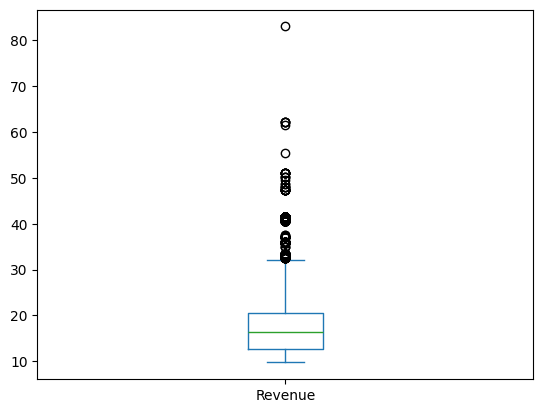

In [50]:
 New['Revenue'].plot.box()


In [51]:
New = New[New['Revenue'] < 50]

In [52]:
IQR = 20.50 - 12.75

In [53]:
Max_out = 20.5 + 3 * IQR
Max_out

43.75

In [54]:
New.head(3)

,date,time,order_id,name,size,price,quantity,Revenue,category,Hour,day,day of the week,month,ingredients,pizza_id,pizza_type_id
0,2015-01-01,11:38:36,1,The Hawaiian Pizza,M,13.25,1,13.25,Classic,11,1,Thursday,1,"Sliced Ham, Pineapple, Mozzarella Cheese",hawaiian_m,hawaiian
1,2015-01-01,11:57:40,2,The Classic Deluxe Pizza,M,16.00,1,16.00,Classic,11,1,Thursday,1,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",classic_dlx_m,classic_dlx
2,2015-01-01,11:57:40,2,The Five Cheese Pizza,L,18.50,1,18.50,Veggie,11,1,Thursday,1,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",five_cheese_l,five_cheese


In [55]:
New.to_csv('Pizzas_Cleaned.csv')

# Analysis

In [56]:
New.groupby('day of the week').agg(Unique_Orders=('order_id', 'nunique')).reset_index().rename(columns={'day of the week': 'Day Name'}).sort_values(by='Unique_Orders', ascending=False)

,Day Name,Unique_Orders
0,Friday,3538
4,Thursday,3239
2,Saturday,3158
6,Wednesday,3024
5,Tuesday,2973
1,Monday,2794
3,Sunday,2624


In [57]:
New.groupby('Hour')['quantity'].sum().sort_values(ascending=False)

,quantity
Hour,
12,6757
13,6402
18,5411
17,5209
19,4406
16,4239
14,3604
20,3534
15,3216


In [58]:
pivot_results = pd.pivot_table(
    New,
    index=['day of the week','Hour'],
    values=['order_id','quantity'],
    aggfunc={'order_id': 'nunique', 'quantity': 'sum'}
)


pivot_results.columns = ['Unique Orders', 'Total Pizzas']
display(pivot_results)

Unique Orders  Total Pizzas
day of the week Hour                             
Friday          11              192           388
                12              415          1098
                13              413          1038
                14              221           522
                15              190           441
...                             ...           ...
Wednesday       18              335           756
                19              238           516
                20              193           398
                21              139           271
                22               72           146

[95 rows x 2 columns]

## AOV

In [59]:
total_revenue_per_order = New.groupby('order_id')['Revenue'].sum()
total_revenue_per_order.head()

,Revenue
order_id,
1,13.25
2,92.00
3,37.25
4,16.50
5,16.50


In [60]:
average_order_value = total_revenue_per_order.mean()
print(f"The Average Order Value (AOV) is: ${average_order_value:.2f}")

The Average Order Value (AOV) is: $38.26


In [61]:
New.head(1)

,date,time,order_id,name,size,price,quantity,Revenue,category,Hour,day,day of the week,month,ingredients,pizza_id,pizza_type_id
0,2015-01-01,11:38:36,1,The Hawaiian Pizza,M,13.25,1,13.25,Classic,11,1,Thursday,1,"Sliced Ham, Pineapple, Mozzarella Cheese",hawaiian_m,hawaiian


In [62]:
orders_by_date_hour = pd.pivot_table(New, index=['date', 'Hour'], values='order_id', aggfunc='nunique')
orders_by_date_hour.head()

order_id
date       Hour          
2015-01-01 11           2
           12           7
           13          10
           14           7
           15           7

In [63]:
orders_by_date_hour.to_csv('orders_by_date_hour.csv')
print("Pivot table 'orders_by_date_hour.csv' saved successfully.")

Pivot table 'orders_by_date_hour.csv' saved successfully.


In [64]:
orders_by_date_hour.head()

order_id
date       Hour          
2015-01-01 11           2
           12           7
           13          10
           14           7
           15           7

In [65]:
busiest_hours = orders_by_date_hour.groupby('Hour')['order_id'].sum()
print("Total unique orders by hour:\n", busiest_hours.sort_values(ascending=False))

Total unique orders by hour:
 Hour
12    2520
13    2455
18    2399
17    2336
19    2009
16    1920
20    1642
14    1472
15    1468
11    1231
21    1198
22     663
23      28
10       8
9        1
Name: order_id, dtype: int64


In [66]:
busiest_days = orders_by_date_hour.groupby('date')['order_id'].sum()
print("Total unique orders by day:\n", busiest_days.sort_values(ascending=False).head())

Total unique orders by day:
 date
2015-11-27    115
2015-11-26    113
2015-10-15    107
2015-07-04    105
2015-05-15     94
Name: order_id, dtype: int64


In [67]:
capacity_exceeded_periods = orders_by_date_hour[orders_by_date_hour['order_id'] > 15]
capacity_exceeded_periods.head()

order_id
date       Hour          
2015-06-27 18          16
2015-07-24 18          18
2015-08-14 13          16
2015-10-15 13          19
           17          18

In [68]:
total_overload_incidents = len(capacity_exceeded_periods)
print(f"Total number of overload incidents: {total_overload_incidents}")

Total number of overload incidents: 7


In [69]:
average_orders_during_overload = capacity_exceeded_periods['order_id'].mean()
print(f"Average unique orders during overload incidents: {average_orders_during_overload:.2f}")

Average unique orders during overload incidents: 17.43


In [70]:
New.head(1)

,date,time,order_id,name,size,price,quantity,Revenue,category,Hour,day,day of the week,month,ingredients,pizza_id,pizza_type_id
0,2015-01-01,11:38:36,1,The Hawaiian Pizza,M,13.25,1,13.25,Classic,11,1,Thursday,1,"Sliced Ham, Pineapple, Mozzarella Cheese",hawaiian_m,hawaiian


In [71]:
pizza_hour_date = pd.pivot_table(New,index=['date','Hour'],values ='quantity',aggfunc='sum')

In [72]:
pizza_hour_date.to_csv('pizza_datetime.csv')